# Prime Number Theorem — Analysis & Verification

This notebook verifies and compares partial function constructions that certificate the Prime Number Theorem.

**Problem:** Find a partial function $f$ that maximizes
$$S(f) = -\sum_k f(k) \frac{\log k}{k}$$
subject to normalization ($\sum_k f(k)/k = 0$) and the constraint $\sum_k f(k)\lfloor x/k \rfloor \leq 1$ for all $x \geq 1$. The theoretical maximum is $S = 1$ (the Möbius function).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import sys

sys.path.insert(0, 'solutions')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Verification Function

The verifier (matching the [Einstein Arena](https://einsteinarena.com/problems/prime-number-theorem) scorer):
1. Clips values to $[-10, 10]$
2. Normalizes $f(1)$ so $\sum_k f(k)/k = 0$
3. Monte Carlo constraint check: $\sum_k f(k)\lfloor x/k \rfloor \leq 1$
4. Returns $S(f) = -\sum_k f(k) \log(k) / k$

In [2]:
NUM_SAMPLES = 10_000_000
_TARGET_BATCH_BYTES = 40 * 1024 * 1024

def evaluate(solution: dict) -> float:
    """Exact Einstein Arena verifier for the Prime Number Theorem problem."""
    raw = solution["partial_function"]
    pf = {int(k): np.clip(float(v), -10, 10) for k, v in raw.items()}
    total = sum(v / k for k, v in pf.items())
    pf[1] = pf.get(1, 0.0) - total
    keys = np.array(list(pf.keys()), dtype=np.float64)
    values = np.array(list(pf.values()), dtype=np.float64)
    upper_bound = 10.0 * float(np.max(keys))
    batch_size = max(1, _TARGET_BATCH_BYTES // (len(keys) * 8))
    rng = np.random.RandomState(42)
    remaining = NUM_SAMPLES
    while remaining > 0:
        n = min(batch_size, remaining)
        x = rng.uniform(1, upper_bound, size=n)
        floors = np.floor(x[:, None] / keys[None, :])
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            x_sums = floors @ values
        if np.any(x_sums > 1.0001):
            return float(-np.inf)
        remaining -= n
    return float(-np.sum(values * np.log(keys) / keys))

## 2. Load Solutions

In [3]:
from alphaevolve_2025 import partial_function as ae_pf

with open('solutions/togetherai_2026.json') as f:
    tai_raw = json.load(f)
tai_pf = {int(k): v for k, v in tai_raw["partial_function"].items()}

solutions = [
    ("AlphaEvolve (2025)", ae_pf),
    ("Together AI (2026)", tai_pf),
]

for name, pf in solutions:
    keys = sorted(pf.keys())
    print(f'{name}: {len(pf)} keys, range [{min(keys)}, {max(keys)}]')

AlphaEvolve (2025): 5 keys, range [1, 30]
Together AI (2026): 1785 keys, range [2, 2999]


## 3. Verify Score

In [4]:
print("=" * 70)
print("VERIFICATION OF ALL SOLUTIONS")
print("=" * 70)
print()

scores = {}
for name, pf in solutions:
    solution = {"partial_function": {str(k): v for k, v in pf.items()}}
    score = evaluate(solution)
    scores[name] = score
    print(f'{name}')
    print(f'  Keys:  {len(pf)}')
    print(f'  Score: S(f) = {score:.6f}')
    print(f'  Valid: {"Yes" if score > -np.inf else "FAILED constraint check"}')
    print()

print("=" * 70)
print("COMPARISON TABLE")
print("=" * 70)
print(f"{'Method':<30} {'Keys':>8} {'Score S(f)':>18}")
print("-" * 58)
for name, pf in solutions:
    marker = " <-- best" if scores[name] == max(scores.values()) else ""
    print(f"{name:<30} {len(pf):>8} {scores[name]:>18.6f}{marker}")
print()
print(f"Theoretical maximum: S = 1.000000 (Möbius function)")

VERIFICATION OF ALL SOLUTIONS

AlphaEvolve (2025)
  Keys:  5
  Score: S(f) = 0.921292
  Valid: Yes

Together AI (2026)
  Keys:  1785
  Score: S(f) = 0.994179
  Valid: Yes

COMPARISON TABLE
Method                             Keys         Score S(f)
----------------------------------------------------------
AlphaEvolve (2025)                    5           0.921292
Together AI (2026)                 1785           0.994179 <-- best

Theoretical maximum: S = 1.000000 (Möbius function)


## 4. Visualization

Compare the partial functions: key positions and values.

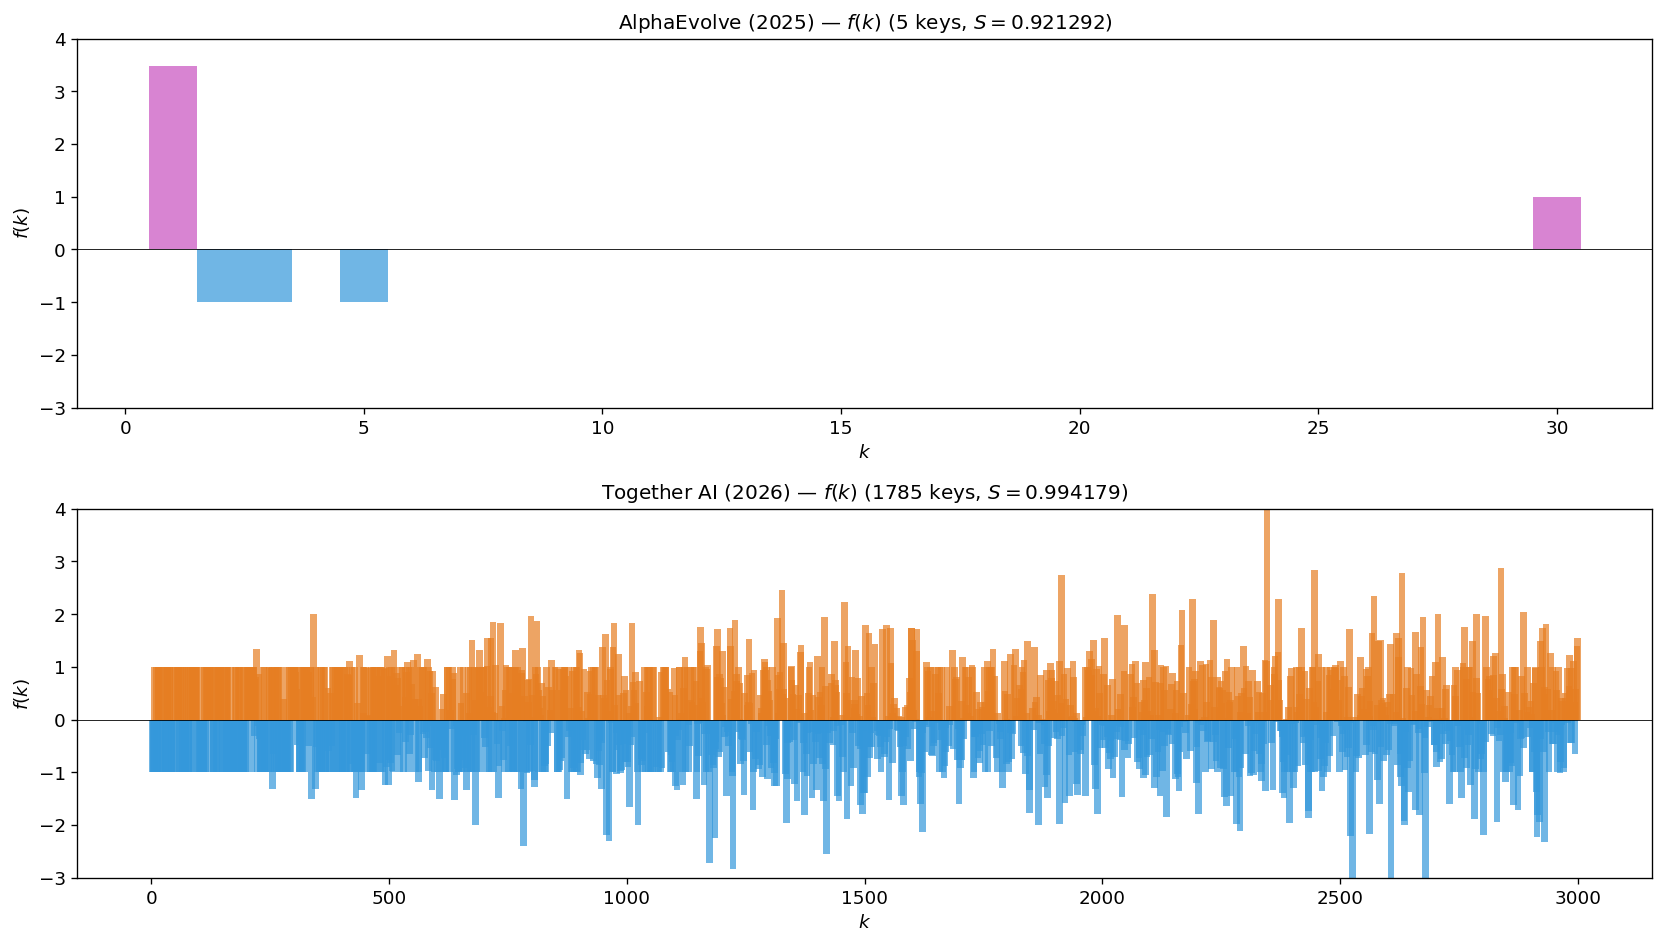

In [5]:
colors = ['#C850C0', '#E67E22']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for idx, ((name, pf), color) in enumerate(zip(solutions, colors)):
    ax = axes[idx]
    keys = sorted(pf.keys())
    vals = [pf[k] for k in keys]
    ax.bar(keys, vals, width=max(1, max(keys) // 200),
           color=np.where(np.array(vals) >= 0, color, '#3498DB'),
           alpha=0.7, edgecolor='none')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{name} — $f(k)$ ({len(pf)} keys, $S = {scores[name]:.6f}$)',
                 fontsize=12)
    ax.set_xlabel('$k$')
    ax.set_ylabel('$f(k)$')
    ax.set_ylim(-3, 4)

plt.tight_layout()
plt.savefig('visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()